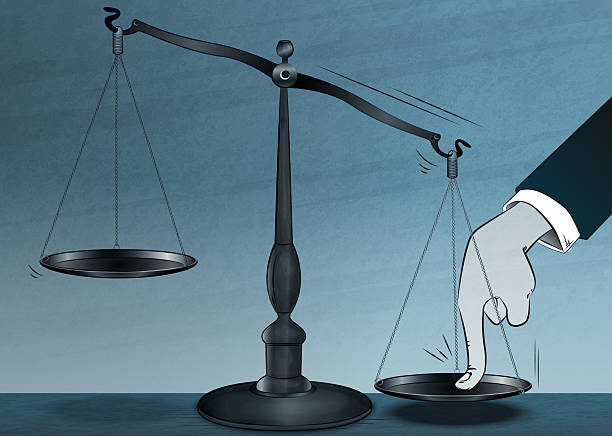

# Can a credit model be unfair even if it never sees gender?

This notebook is a hands-on educational tool for that question. It is built for learning, not for scoring real people.

Many lenders try to make credit decisions fair by leaving gender out of the model. It feels safe: if the model can't see gender, how could it discriminate? This notebook lets you test that idea on a portfolio you design yourself, and see exactly when it breaks.

Here is the mechanism we'll explore. Unfairness needs two ingredients to reach a gender-blind model:

1. **Biased history.** Some genuinely creditworthy women were rejected in the past, and those wrong calls were written into the records as fact.
2. **Proxies.** Some features quietly reveal gender. In real data, things like business sector, occupation, or location often do.

With both ingredients, the model learns the old bias from the proxies and repeats it, no gender column needed. Remove either ingredient and, as you'll be able to verify yourself, the problem largely disappears. That's the honest version of the lesson: hiding gender isn't wrong, it's just not enough.

You answer a few questions about the portfolio you want to simulate. The notebook then builds the data, trains the model, judges its fairness in plain words based on **your** numbers, puts a currency figure on the damage, and shows one way to repair it — along with what the repair costs.

***

## Four fairness questions we will ask

Fairness has no single definition — researchers have written down more than twenty, and it's mathematically impossible to satisfy them all at once. So each lender has to choose. We'll use four that cover the main families of definitions.

**Demographic parity — are we approving men and women at the same rate?** The most intuitive one, and the closest to how regulators think: US guidance flags concern when one group's approval rate falls below four-fifths of the other's. Its known weakness: it ignores whether applicants could actually repay.

**Equal opportunity — among people who truly would repay, do we wrongly reject one gender more?** For the applicant who gets turned away, this is the harm that matters most. Lower wrong-rejection rates are better, and we want them equal.

**Predictive equality — among people who truly would not repay, do we wrongly approve one gender more?** This is the mirror image, and mostly the lender's cost.

**Predictive parity — when we approve someone, are we right equally often for both genders?** Of approved men and approved women, the same share should actually repay.

Equal opportunity and predictive equality together are known as *equalized odds*. In this notebook, a gap of less than 5 percentage points between men and women counts as fair — smaller gaps are usually just noise from the random draw.

***

## Setup

Libraries and the settings gathered in one place.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix

sns.set_style("whitegrid")

RANDOM_STATE       = 1      # fixed so the same inputs always give the same results
N_FEATURES         = 14     # anonymous features per applicant
N_INFORMATIVE      = 8      # how many of them actually carry signal
FAIRNESS_TOLERANCE = 0.05   # gaps under 5 percentage points count as fair
MALE, FEMALE       = 1, 0   # codes used internally

rs = np.random.RandomState(RANDOM_STATE)

***

## A few small helpers

`ask_number` makes the questions robust: type a blank, a word, a decimal where a whole number is needed, or something out of range, and it explains the problem and asks again. The rest are the measuring tools used throughout.

In [2]:
def ask_number(prompt, low=None, high=None, whole=False, above=None):
    """Ask for a number and keep asking until the answer is valid."""
    while True:
        answer = input(prompt).strip()
        if answer == "":
            print("   Nothing entered — please type a number.")
            continue
        try:
            value = float(answer)
        except ValueError:
            print("   That doesn't look like a number — please try again.")
            continue
        if whole and value != int(value):
            print("   Please enter a whole number (no decimals).")
            continue
        if whole:
            value = int(value)
        if low is not None and value < low:
            print("   Please enter a number of at least {}.".format(low))
            continue
        if high is not None and value > high:
            print("   Please enter a number no greater than {}.".format(high))
            continue
        if above is not None and value <= above:
            print("   Please enter a number greater than {}.".format(above))
            continue
        return value


def counts(actual, predicted):
    """True/false positives and negatives, always as a full 2x2 table."""
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
    return tp, fp, fn, tn


def group_table(data, gender_code, profit_per_good, loss_per_bad, thresholds):
    """For one gender: fairness measures and profit at every cutoff, judged against the TRUTH."""
    group = data[data["gender"] == gender_code]
    eps = 1e-7
    rows = []
    for t in thresholds:
        predicted = (group["score"] > t).astype(int)
        tp, fp, fn, tn = counts(group["truth"], predicted)
        rows.append({
            "threshold": t,
            "approval_rate":       (tp + fp) / (tp + fp + fn + tn + eps),
            "equal_opportunity":   fn / (fn + tp + eps),   # wrong rejections of good borrowers
            "predictive_equality": fp / (fp + tn + eps),   # wrong approvals of bad borrowers
            "predictive_parity":   tp / (tp + fp + eps),   # reliability of approvals
            "profit": profit_per_good * tp - loss_per_bad * fp,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        })
    return pd.DataFrame(rows)

***

### The verdict machine

You asked whether the notebook can react to *your* numbers in plain language, whatever they are. It can, and here is the trick: we don't need to anticipate every possible input, only every possible **outcome**. Each fairness check can land in exactly one of three states — fair, unfair against women, or unfair against men. Four checks, three states each: a small, complete set. We write one honest sentence for each state, and the code picks the right one based on the gap it measured.

In [3]:
METRICS = {
    "approval_rate": {
        "label": "Demographic parity — approval rates",
        "fair":  "Men and women are approved at about the same rate ({m:.1f}% vs {f:.1f}%).",
        "women": "Women are approved less often than men ({f:.1f}% vs {m:.1f}%).",
        "men":   "Men are approved less often than women ({m:.1f}% vs {f:.1f}%).",
    },
    "equal_opportunity": {
        "label": "Equal opportunity — wrong rejections of creditworthy applicants",
        "fair":  "Creditworthy men and women are wrongly rejected at about the same rate ({m:.1f}% vs {f:.1f}%).",
        "women": "Creditworthy women are wrongly rejected more often than creditworthy men ({f:.1f}% vs {m:.1f}%).",
        "men":   "Creditworthy men are wrongly rejected more often than creditworthy women ({m:.1f}% vs {f:.1f}%).",
    },
    "predictive_equality": {
        "label": "Predictive equality — wrong approvals of uncreditworthy applicants",
        "fair":  "Uncreditworthy applicants slip through at about the same rate for both ({m:.1f}% vs {f:.1f}%).",
        "women": "Uncreditworthy men are approved more often than uncreditworthy women ({m:.1f}% vs {f:.1f}%).",
        "men":   "Uncreditworthy women are approved more often than uncreditworthy men ({f:.1f}% vs {m:.1f}%).",
    },
    "predictive_parity": {
        "label": "Predictive parity — reliability of approvals",
        "fair":  "Approvals are about equally reliable for both ({m:.1f}% vs {f:.1f}% of approved applicants repay).",
        "women": "Approved women repay less often than approved men ({f:.1f}% vs {m:.1f}%), so approvals of women are treated as less reliable.",
        "men":   "Approved men repay less often than approved women ({m:.1f}% vs {f:.1f}%), so approvals of men are treated as less reliable.",
    },
}

def verdict(metric, men_value, women_value):
    """Return (state, sentence) for one fairness check. State is 'fair', 'women' or 'men'."""
    gap = men_value - women_value
    if abs(gap) <= FAIRNESS_TOLERANCE:
        state = "fair"
    elif metric in ("approval_rate", "predictive_parity"):
        state = "women" if gap > 0 else "men"     # higher value = better treated
    elif metric == "predictive_equality":
        state = "women" if gap > 0 else "men"     # higher FPR = that group favoured, other disadvantaged
    else:                                          # equal_opportunity: higher FNR = that group harmed
        state = "men" if gap > 0 else "women"
    text = METRICS[metric][state].format(m=men_value * 100, f=women_value * 100)
    flag = "Fair" if state == "fair" else "Not fair"
    return state, "{}  [{}]\n   {}".format(METRICS[metric]["label"], flag, text)


def summary(states):
    """One honest paragraph for the overall picture, whatever it is."""
    broken = [k for k, s in states.items() if s != "fair"]
    if not broken:
        return ("All four checks pass. With these inputs, the model treats men and women "
                "about the same — try raising the bias level or the proxy strength and run again.")
    against_women = [k for k in broken if states[k] == "women"]
    against_men   = [k for k in broken if states[k] == "men"]
    if len(against_women) == len(broken):
        return ("{} of the four checks fail, and every failure points the same way: "
                "against women. This is a model repeating the bias in its training data.").format(len(broken))
    if len(against_men) == len(broken):
        return ("{} of the four checks fail, all against men — an unusual pattern worth "
                "investigating in your inputs.").format(len(broken))
    return ("{} of the four checks fail, in mixed directions: {} against women, {} against men. "
            "Mixed pictures like this are common in practice — it is why a lender has to decide "
            "which fairness definition it cares about most.").format(
                len(broken), len(against_women), len(against_men))

***

## Step 1 — Describe your portfolio

Eight questions. The first five shape the applicants and the history; the last three set the economics of a loan. Suggested starting values are in brackets.  But the whole point is to try your own.

In [4]:
total_customers = ask_number(
    "1. How many customers should the portfolio have? (at least 500; try 2000) ",
    low=500, whole=True)

male_share = ask_number(
    "2. What share of them are men? (0 to 1; try 0.6) ",
    low=0.01, high=0.99)

base_rate = ask_number(
    "3. What share of ALL applicants would truly repay a loan? (0.05 to 0.95; try 0.55)\n"
    "   We assume men and women are equally creditworthy, so any gap we find later is caused by bias. ",
    low=0.05, high=0.95)

bias_level = ask_number(
    "4. Historical bias: what share of truly creditworthy women were wrongly recorded\n"
    "   as bad borrowers in your past data? (0 to 0.5; try 0.2; enter 0 for no bias) ",
    low=0.0, high=0.5)

proxy_strength = ask_number(
    "5. Proxy strength: how much do your features quietly reveal gender?\n"
    "   In real data, sector, occupation or location often do. (0 to 1; try 0.7; 0 = not at all) ",
    low=0.0, high=1.0)

loan_size = ask_number(
    "6. Average loan size, in your currency? (try 1000) ",
    above=0)

interest_rate = ask_number(
    "7. Interest earned over the life of a repaid loan, as a fraction? (e.g. 0.2 for 20%) ",
    low=0.01, high=0.99)

lgd = ask_number(
    "8. Loss given default: what fraction of the loan do you lose when a borrower\n"
    "   defaults, after collateral and collections? (must be larger than the interest rate) ",
    above=interest_rate, high=1.0)

n_men   = int(total_customers * male_share)
n_women = total_customers - n_men

profit_per_good = loan_size * interest_rate
loss_per_bad    = loan_size * lgd

print()
print("Your portfolio: {} men and {} women.".format(n_men, n_women))
print("A repaid loan earns you {:,.0f}; a defaulted loan costs you {:,.0f}.".format(
    profit_per_good, loss_per_bad))

1. How many customers should the portfolio have? (at least 500; try 2000) 2000
2. What share of them are men? (0 to 1; try 0.6) 0.6
3. What share of ALL applicants would truly repay a loan? (0.05 to 0.95; try 0.55)
   We assume men and women are equally creditworthy, so any gap we find later is caused by bias. 0.8
4. Historical bias: what share of truly creditworthy women were wrongly recorded
   as bad borrowers in your past data? (0 to 0.5; try 0.2; enter 0 for no bias) 0.18
5. Proxy strength: how much do your features quietly reveal gender?
   In real data, sector, occupation or location often do. (0 to 1; try 0.7; 0 = not at all) 0.3
6. Average loan size, in your currency? (try 1000) 1000
7. Interest earned over the life of a repaid loan, as a fraction? (e.g. 0.2 for 20%) 0.2
8. Loss given default: what fraction of the loan do you lose when a borrower
   defaults, after collateral and collections? (must be larger than the interest rate) 0.4

Your portfolio: 1200 men and 800 women.


***

## Step 2 — Build the population, then rewrite its history

Three moves here, and the order matters.

**First, one shared population.** Every applicant gets fourteen anonymous features and a *true* answer: would this person repay, yes or no. Men and women are drawn from the same pool, so by construction they are equally creditworthy.

**Second, gender with proxies.** We assign gender partly at random and partly through one of the features, at the strength you chose. This mimics real data, where no column says "gender" but sector or location whispers it.

**Third, the bias.** We keep two labels for every applicant. `truth` is whether they would really repay — in a simulation we're allowed to know that. `recorded` is what the bank's files say, and this is where we do the damage: for the share of creditworthy women you chose, we flip their recorded label to "bad borrower". A right answer, overwritten by an old prejudice, and filed as fact.

The bank only ever sees `recorded`. We keep `truth` so that later we can measure the harm honestly — including harm the bank's own records would hide from it.

In [5]:
# One shared population — the truth
X, y = make_classification(
    n_samples=total_customers, weights=[1 - base_rate, base_rate],
    n_features=N_FEATURES, n_informative=N_INFORMATIVE,
    n_classes=2, random_state=RANDOM_STATE)

portfolio = pd.DataFrame(X, columns=["feature_{}".format(i) for i in range(1, N_FEATURES + 1)])
portfolio["truth"] = y

# Gender, partly driven by a proxy feature
proxy_driven = int(proxy_strength * n_women)
order = np.argsort(-portfolio["feature_1"].values)          # applicants ranked by the proxy
female_idx = list(order[:proxy_driven])                     # this share of women follow the proxy...
remaining = np.setdiff1d(np.arange(total_customers), female_idx)
female_idx += list(rs.choice(remaining, size=n_women - proxy_driven, replace=False))  # ...the rest are random

portfolio["gender"] = MALE
portfolio.loc[female_idx, "gender"] = FEMALE

# The recorded label — history, with your chosen level of bias against women
portfolio["recorded"] = portfolio["truth"]
creditworthy_women = portfolio.index[(portfolio["gender"] == FEMALE) & (portfolio["truth"] == 1)].values
flipped = rs.choice(creditworthy_women, size=int(len(creditworthy_women) * bias_level), replace=False)
portfolio.loc[flipped, "recorded"] = 0

print("Population built: {} applicants, {} of them truly creditworthy.".format(
    len(portfolio), int(portfolio["truth"].sum())))
print("Records rewritten: {} creditworthy women now filed as bad borrowers.".format(len(flipped)))

Population built: 2000 applicants, 1597 of them truly creditworthy.
Records rewritten: 114 creditworthy women now filed as bad borrowers.


***

## Step 3 — Train the model, without gender

The model gets the fourteen features and the `recorded` labels — exactly what a real bank would have. Gender never goes in, and neither does `truth`.

One piece of good practice: instead of scoring applicants with a model that was trained on them, we use five-fold cross-validation, so every applicant's score comes from a model that never saw them. It's the honest way to measure, and it uses the whole portfolio rather than a small test slice.

In [6]:
feature_cols = [c for c in portfolio.columns if c.startswith("feature_")]

portfolio["score"] = cross_val_predict(
    LogisticRegression(solver="lbfgs", max_iter=1000),
    portfolio[feature_cols].values, portfolio["recorded"].values,
    cv=5, method="predict_proba")[:, 1]

print("Every applicant now has a score between 0 and 1 — "
      "the model's estimate of how likely they are to repay.")
portfolio[["score", "gender", "truth", "recorded"]].head()

Every applicant now has a score between 0 and 1 — the model's estimate of how likely they are to repay.


,score,gender,truth,recorded
0,0.964723,0,1,1
1,0.848023,1,1,1
2,0.654837,1,0,0
3,0.971632,0,1,1
4,0.939611,1,1,1


***

## Step 4 — Where should the cutoff be? The economics say exactly where.

A score isn't a decision; you need a cutoff. And with the loan economics you gave, the profit-maximising cutoff isn't a mystery — it has a formula. Approving someone with repayment probability *p* is worth it when the expected gain beats the expected loss:

&nbsp;&nbsp;&nbsp;&nbsp;*p* × profit > (1 − *p*) × loss

Solve for *p* and the loan size cancels out:

&nbsp;&nbsp;&nbsp;&nbsp;**cutoff = loss ÷ (loss + profit) = LGD ÷ (LGD + interest rate)**

That's why lenders are conservative: when you can lose three times what you can earn, the math itself tells you to demand a 75% repayment probability. Below, we compute the theoretical cutoff, then check it against a brute-force scan of every cutoff from 0.01 to 0.99. If the two agree, the model's scores are well calibrated — a score of 0.7 really behaves like a 70% chance. If they disagree, that's the scores drifting from reality, and the notebook will say so.

***

In [7]:
theory_cutoff = loss_per_bad / (loss_per_bad + profit_per_good)

thresholds  = np.round(np.arange(0.01, 1.00, 0.01), 2)
men_table   = group_table(portfolio, MALE,   profit_per_good, loss_per_bad, thresholds)
women_table = group_table(portfolio, FEMALE, profit_per_good, loss_per_bad, thresholds)

total_profit = men_table["profit"].values + women_table["profit"].values
best         = int(np.argmax(total_profit))
scan_cutoff  = thresholds[best]

print("Theory says the cutoff should be:   {:.2f}".format(theory_cutoff))
print("The scan of all 99 cutoffs found:   {:.2f}  (profit {:,.0f})".format(
    scan_cutoff, total_profit[best]))
print()
if abs(scan_cutoff - theory_cutoff) <= 0.05:
    print("They agree. The model's scores are well calibrated — a predicted 70% chance")
    print("of repayment really does behave like one — so we can trust the cutoff.")
    profit_cutoff = scan_cutoff
else:
    print("They disagree by {:.2f}. That gap means the scores are not perfectly calibrated —".format(
        abs(scan_cutoff - theory_cutoff)))
    print("the model's '70%' is not a true 70%. We will use the scanned cutoff, since it")
    print("reflects what actually happens, but this is exactly why calibration matters.")
    profit_cutoff = scan_cutoff

Theory says the cutoff should be:   0.67
The scan of all 99 cutoffs found:   0.58  (profit 216,400)

They disagree by 0.09. That gap means the scores are not perfectly calibrated —
the model's '70%' is not a true 70%. We will use the scanned cutoff, since it
reflects what actually happens, but this is exactly why calibration matters.


Before judging fairness, one look at that calibration claim. This chart groups applicants by their predicted score and asks: of the people the model gave this score to, how many truly repay? A well-calibrated model hugs the diagonal — and we draw it separately for men and women, because a model can be calibrated for one group and not the other.

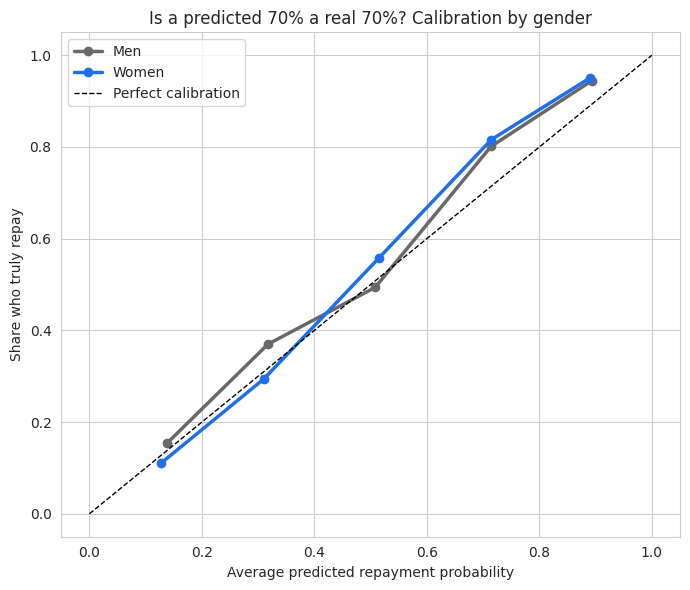

If the women's line sits above the men's, women repay MORE often than their scores
claim — the model is quietly underrating them. That is biased history at work.


In [8]:
portfolio["score_bin"] = pd.cut(portfolio["score"], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.figure(figsize=(7, 6))
for gender_code, label, color in [(MALE, "Men", "dimgrey"), (FEMALE, "Women", "#1f6feb")]:
    grp = portfolio[portfolio["gender"] == gender_code]
    curve = grp.groupby("score_bin", observed=False).agg(
        predicted=("score", "mean"), actual=("truth", "mean")).dropna()
    plt.plot(curve["predicted"], curve["actual"], "o-", lw=2.5, color=color, label=label)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
plt.xlabel("Average predicted repayment probability")
plt.ylabel("Share who truly repay")
plt.title("Is a predicted 70% a real 70%? Calibration by gender")
plt.legend()
plt.tight_layout(); plt.show()

print("If the women's line sits above the men's, women repay MORE often than their scores")
print("claim — the model is quietly underrating them. That is biased history at work.")

***

## Step 5 — The verdict, in your numbers

Now the four fairness checks at the profit cutoff, judged against the **truth** — not against the biased records. Every sentence below is chosen by the verdict machine based on what your inputs actually produced.

In [9]:
men_now   = men_table.iloc[best]
women_now = women_table.iloc[best]

print("Fairness at cutoff {:.2f}".format(profit_cutoff))
print("=" * 70)
states = {}
for metric in METRICS:
    state, text = verdict(metric, men_now[metric], women_now[metric])
    states[metric] = state
    print()
    print(text)

print()
print("=" * 70)
print("Overall: " + summary(states))

# The regulator's yardstick: the four-fifths rule on approval rates
hi = max(men_now["approval_rate"], women_now["approval_rate"])
lo = min(men_now["approval_rate"], women_now["approval_rate"])
ratio = lo / (hi + 1e-9)
print()
if ratio >= 0.8:
    print("Four-fifths rule: PASS. The lower approval rate is {:.0f}% of the higher one — "
          "above the 80% line US regulators use as a warning threshold.".format(ratio * 100))
else:
    print("Four-fifths rule: FAIL. The lower approval rate is only {:.0f}% of the higher one — "
          "below the 80% line, which US regulators treat as evidence of disparate impact.".format(ratio * 100))

# Honesty about sample size
smallest = min((portfolio["gender"] == MALE).sum(), (portfolio["gender"] == FEMALE).sum())
if smallest < 200:
    print()
    print("A caution: your smaller group has only {} people, so these percentages are "
          "rough. Re-run with a larger portfolio for steadier numbers.".format(smallest))

Fairness at cutoff 0.58

Demographic parity — approval rates  [Fair]
   Men and women are approved at about the same rate (81.1% vs 80.0%).

Equal opportunity — wrong rejections of creditworthy applicants  [Fair]
   Creditworthy men and women are wrongly rejected at about the same rate (10.0% vs 10.3%).

Predictive equality — wrong approvals of uncreditworthy applicants  [Fair]
   Uncreditworthy applicants slip through at about the same rate for both (44.7% vs 42.8%).

Predictive parity — reliability of approvals  [Fair]
   Approvals are about equally reliable for both (89.1% vs 88.9% of approved applicants repay).

Overall: All four checks pass. With these inputs, the model treats men and women about the same — try raising the bias level or the proxy strength and run again.

Four-fifths rule: PASS. The lower approval rate is 99% of the higher one — above the 80% line US regulators use as a warning threshold.


***

## Step 6 — Fairness at every possible cutoff

The verdicts above describe one cutoff. These four charts show each measure across all of them, for men (grey) and women (blue). The gap between the lines is the unfairness; where they touch, a fair cutoff exists for that measure (dashed purple). The dotted green line is where profit put us.

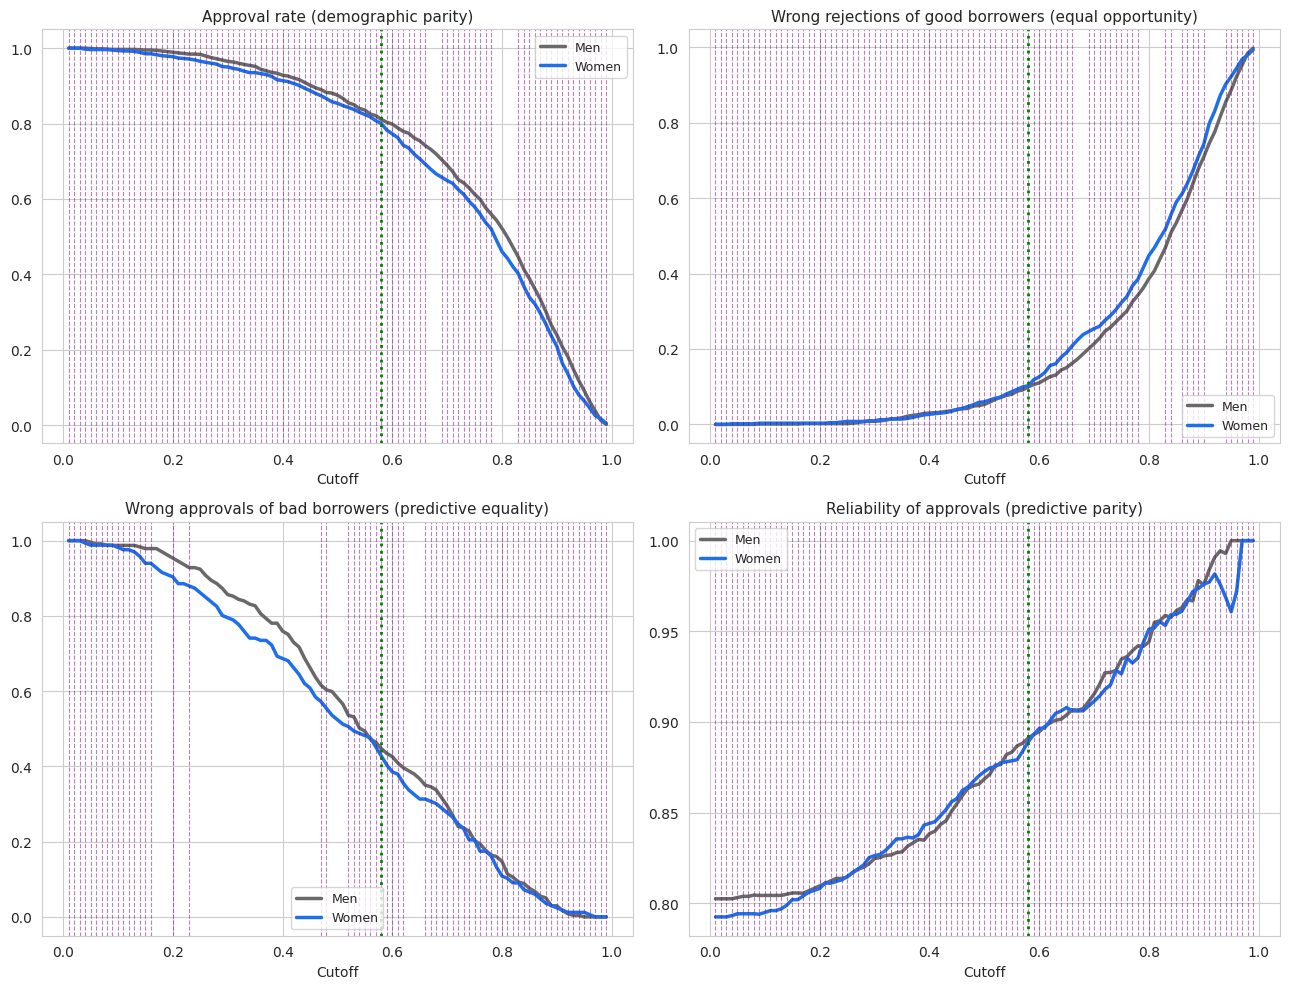

Dashed purple: a fair cutoff exists there for that measure.
Dotted green: the profit-maximising cutoff we actually chose.


In [10]:
def fair_cutoffs(metric):
    gap = men_table[metric].values - women_table[metric].values
    within   = thresholds[np.abs(gap) <= FAIRNESS_TOLERANCE]
    crossing = thresholds[1:][np.sign(gap[:-1]) != np.sign(gap[1:])]
    return sorted(set(np.round(np.concatenate([within, crossing]), 2)))

panels = [
    ("approval_rate",       "Approval rate (demographic parity)"),
    ("equal_opportunity",   "Wrong rejections of good borrowers (equal opportunity)"),
    ("predictive_equality", "Wrong approvals of bad borrowers (predictive equality)"),
    ("predictive_parity",   "Reliability of approvals (predictive parity)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (metric, title) in zip(axes.ravel(), panels):
    ax.plot(thresholds, men_table[metric],   color="dimgrey", lw=2.5, label="Men")
    ax.plot(thresholds, women_table[metric], color="#1f6feb", lw=2.5, label="Women")
    for c in fair_cutoffs(metric):
        ax.axvline(c, color="purple", ls="--", lw=0.8, alpha=0.5)
    ax.axvline(profit_cutoff, color="green", ls=":", lw=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Cutoff")
    ax.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()

print("Dashed purple: a fair cutoff exists there for that measure.")
print("Dotted green: the profit-maximising cutoff we actually chose.")

***

## Step 7 — Would a fancier model fix it?

A fair question: maybe the unfairness is logistic regression's fault, and a modern model would make it go away. Let's test that claim directly — same data, same cutoff, two stronger models: a random forest and gradient boosting.

One technical honesty note: these tree-based models produce poorly calibrated scores out of the box (their "0.7" is not a real 70%), so we wrap them in a calibration step before comparing. That's also the practical reason logistic regression is still the workhorse of regulated lending — its scores are naturally close to calibrated, and its decisions can be explained to a customer.

In [11]:
models = {
    "Logistic regression": LogisticRegression(solver="lbfgs", max_iter=1000),
    "Random forest (calibrated)": CalibratedClassifierCV(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), cv=3),
    "Gradient boosting (calibrated)": CalibratedClassifierCV(
        GradientBoostingClassifier(random_state=RANDOM_STATE), cv=3),
}

print("Wrong-rejection rate of truly creditworthy applicants, at cutoff {:.2f}:".format(profit_cutoff))
print()
print("{:32s} {:>8s} {:>8s} {:>8s}".format("Model", "Men", "Women", "Gap"))
print("-" * 60)

gaps = {}
for name, mdl in models.items():
    scores = cross_val_predict(mdl, portfolio[feature_cols].values,
                               portfolio["recorded"].values,
                               cv=5, method="predict_proba")[:, 1]
    row = {}
    for gender_code, tag in [(MALE, "men"), (FEMALE, "women")]:
        grp = portfolio[portfolio["gender"] == gender_code]
        predicted = (scores[grp.index] > profit_cutoff).astype(int)
        tp, fp, fn, tn = counts(grp["truth"], predicted)
        row[tag] = fn / (fn + tp + 1e-7)
    gaps[name] = row["women"] - row["men"]
    print("{:32s} {:7.1f}% {:7.1f}% {:+7.1f}".format(
        name, row["men"] * 100, row["women"] * 100, gaps[name] * 100))

print()
still_unfair = [n for n, g in gaps.items() if abs(g) > FAIRNESS_TOLERANCE]
if len(still_unfair) == len(gaps):
    print("Every model shows the gap. Changing the algorithm did not fix the problem,")
    print("because the problem was never the algorithm — it is in the data.")
elif not still_unfair:
    print("No model shows a meaningful gap with these inputs — consistent with low bias")
    print("or weak proxies. Try raising them in Step 1 and running again.")
else:
    print("The gap shrinks for some models but not others. Model choice can soften data")
    print("bias, but as long as biased labels and proxies remain, it does not remove it.")

Wrong-rejection rate of truly creditworthy applicants, at cutoff 0.58:

Model                                 Men    Women      Gap
------------------------------------------------------------
Logistic regression                 10.0%    10.3%    +0.3
Random forest (calibrated)           6.5%     7.9%    +1.3
Gradient boosting (calibrated)       6.7%     8.0%    +1.3

No model shows a meaningful gap with these inputs — consistent with low bias
or weak proxies. Try raising them in Step 1 and running again.


***

## Step 8 — What the unfairness costs you

It's tempting to file fairness under ethics and profit under business. But every truly creditworthy applicant the model rejects is a good loan you didn't make. Because we kept the `truth` column, we can count exactly what the bias costs — including losses the bank's own biased records would hide from it.

In [12]:
rejected_good_women = int(women_now["fn"])
rejected_good_men   = int(men_now["fn"])
forgone_women = rejected_good_women * profit_per_good
forgone_men   = rejected_good_men * profit_per_good

print("At cutoff {:.2f}:".format(profit_cutoff))
print("   Truly creditworthy women wrongly rejected: {:4d}  ->  {:>12,.0f} in forgone profit".format(
    rejected_good_women, forgone_women))
print("   Truly creditworthy men wrongly rejected:   {:4d}  ->  {:>12,.0f} in forgone profit".format(
    rejected_good_men, forgone_men))
print()

women_rate = women_now["equal_opportunity"]
men_rate   = men_now["equal_opportunity"]
if women_rate > men_rate + FAIRNESS_TOLERANCE:
    print("Per creditworthy applicant, women are turned away at {:.1f}% versus {:.1f}% for men.".format(
        women_rate * 100, men_rate * 100))
    print("The bias is not just unfair — it is a machine for refusing good customers.")
elif men_rate > women_rate + FAIRNESS_TOLERANCE:
    print("Per creditworthy applicant, men are turned away at {:.1f}% versus {:.1f}% for women —".format(
        men_rate * 100, women_rate * 100))
    print("an unusual direction worth tracing back to your inputs.")
else:
    print("The wrong-rejection burden is spread roughly evenly between the groups here,")
    print("but every one of these rejections is still profit refused.")

At cutoff 0.58:
   Truly creditworthy women wrongly rejected:   65  ->        13,000 in forgone profit
   Truly creditworthy men wrongly rejected:     96  ->        19,200 in forgone profit

The wrong-rejection burden is spread roughly evenly between the groups here,
but every one of these rejections is still profit refused.


***

## Step 9 — One honest repair: different cutoffs for different groups

If one shared cutoff produces unfair outcomes, the most direct fix is to stop sharing it: one cutoff for men, another for women, chosen so the fairness measure you care about comes out equal. This is the post-processing approach of Hardt, Price and Srebro (2016), and it has a practical virtue — it treats the model as a black box, so it works on any scoring system, even one you bought from a vendor and can't retrain.

We'll repair **equal opportunity**, since wrongly rejecting a creditworthy applicant is the harm that matters most to the person on the other side of the desk. The search below tries every pair of cutoffs, keeps the pairs that close the gap, and among those picks the most profitable.

In [13]:
def most_profitable_fair_pair(metric):
    men_vals   = men_table[metric].values[:, None]
    women_vals = women_table[metric].values[None, :]
    gap    = np.abs(men_vals - women_vals)
    profit = men_table["profit"].values[:, None] + women_table["profit"].values[None, :]
    feasible = np.where(gap <= FAIRNESS_TOLERANCE, profit, -np.inf)
    if not np.isfinite(feasible).any():
        return None
    i, j = np.unravel_index(np.argmax(feasible), feasible.shape)
    return {"i": i, "j": j, "men_cutoff": thresholds[i], "women_cutoff": thresholds[j],
            "profit": profit[i, j]}

single_profit = total_profit[best]

# The honest baseline: the best profit two cutoffs can earn with NO fairness requirement.
# The single cutoff is just the special case where both cutoffs are equal, so this
# baseline is always at least as high — and it is the right yardstick for the cost
# of fairness, since the fair repair also uses two cutoffs.
best_m = int(np.argmax(men_table["profit"].values))
best_w = int(np.argmax(women_table["profit"].values))
pair_baseline = men_table["profit"].values[best_m] + women_table["profit"].values[best_w]

repair = most_profitable_fair_pair("equal_opportunity")

print("Profit with one shared cutoff:            {:,.0f}".format(single_profit))
print("Profit with two cutoffs, no fairness rule: {:,.0f}  (cutoffs {:.2f} / {:.2f})".format(
    pair_baseline, thresholds[best_m], thresholds[best_w]))
print()

if repair is None:
    print("No pair of cutoffs closes the equal-opportunity gap below {:.0f} points for".format(
        FAIRNESS_TOLERANCE * 100))
    print("this portfolio — with inputs this extreme, threshold adjustment alone cannot")
    print("repair the damage, and the fix has to happen earlier, in the data itself.")
else:
    cost = pair_baseline - repair["profit"]
    print("Repair found.")
    print("   Cutoff for men:   {:.2f}".format(repair["men_cutoff"]))
    print("   Cutoff for women: {:.2f}".format(repair["women_cutoff"]))
    print("   Profit: {:,.0f}".format(repair["profit"]))
    print()
    if cost > 0:
        print("Measured against the two-cutoff baseline, this fairness costs {:,.0f} —".format(cost))
        print("about {:.1f}% of profit. The baseline was, by definition, the most money two".format(
            100 * cost / max(abs(pair_baseline), 1e-9)))
        print("cutoffs can make; being fair here means knowingly giving some of it up.")
    else:
        print("The fairness requirement costs nothing here: the profit-maximising pair of")
        print("cutoffs already treats the groups evenly on this measure. The constraint is")
        print("simply not binding at your inputs — turn the bias up and it will start to bite.")
    if repair["profit"] > single_profit:
        print()
        print("Note that the fair pair also out-earns the single shared cutoff. That is not")
        print("magic: two cutoffs are two dials instead of one, and the extra flexibility is")
        print("worth money by itself. This is why the honest cost of fairness is measured")
        print("against the two-cutoff baseline above, not against the single cutoff.")

Profit with one shared cutoff:            216,400
Profit with two cutoffs, no fairness rule: 216,400  (cutoffs 0.57 / 0.58)

Repair found.
   Cutoff for men:   0.57
   Cutoff for women: 0.58
   Profit: 216,400

The fairness requirement costs nothing here: the profit-maximising pair of
cutoffs already treats the groups evenly on this measure. The constraint is
simply not binding at your inputs — turn the bias up and it will start to bite.


### What did the repair do to the other three measures?

We fixed one fairness definition. The famous impossibility results — Chouldechova (2017), Kleinberg et al. (2016) — prove that when two groups differ in their *true* repayment rates, you cannot have calibration-style fairness and error-rate-style fairness at the same time: repairing one must bend the other.

So watch closely what happens below, and notice which world you are in. In this notebook we made men and women equally creditworthy *on purpose* (Step 1, question 3), and with equal true rates the theorem's trap doesn't spring — the measures are allowed to move together. Real portfolios are rarely so kind: when groups genuinely differ in repayment rates, for structural and historical reasons, the conflict is guaranteed.

In [14]:
if repair is not None:
    men_after   = men_table.iloc[repair["i"]]
    women_after = women_table.iloc[repair["j"]]

    print("What the repair did to each fairness gap (percentage points):")
    print()
    print("{:45s} {:>8s} {:>8s}".format("", "Before", "After"))
    print("-" * 64)
    moved = {"better": [], "worse": []}
    for metric in METRICS:
        before = abs(men_now[metric]   - women_now[metric])
        after  = abs(men_after[metric] - women_after[metric])
        if after < before - 0.005:
            moved["better"].append(METRICS[metric]["label"].split(" — ")[0])
        elif after > before + 0.005:
            moved["worse"].append(METRICS[metric]["label"].split(" — ")[0])
        print("{:45s} {:7.1f} {:8.1f}".format(
            METRICS[metric]["label"].split(" — ")[0], before * 100, after * 100))

    print()
    if moved["worse"]:
        print("Repairing equal opportunity improved {}, but pushed {} further out.".format(
            " and ".join(moved["better"]) if moved["better"] else "little else",
            " and ".join(moved["worse"])))
        print("That is the impossibility result in action: fairness definitions compete,")
        print("and fixing one can break another. A lender cannot have them all — it must")
        print("choose which one it will stand behind, and own that choice.")
    else:
        print("Every gap narrowed together. That is not luck — it follows from a choice we")
        print("made in Step 2: men and women here are equally creditworthy by construction,")
        print("and when true repayment rates match, fairness measures are free to align.")
        print("Real portfolios rarely enjoy that guarantee. Where groups differ in true")
        print("repayment rates, the impossibility theorem bites: calibration-based and")
        print("error-rate-based fairness cannot both hold, and repairing one bends the")
        print("other. The peace between the definitions you see here is borrowed from an")
        print("assumption — a good thing to remember before promising all of them at once.")
else:
    print("(No repair was possible above, so there is nothing to re-measure here.)")

What the repair did to each fairness gap (percentage points):

                                                Before    After
----------------------------------------------------------------
Demographic parity                                1.1      2.1
Equal opportunity                                 0.3      1.1
Predictive equality                               2.0      3.6
Predictive parity                                 0.2      0.1

Repairing equal opportunity improved little else, but pushed Demographic parity and Equal opportunity and Predictive equality further out.
That is the impossibility result in action: fairness definitions compete,
and fixing one can break another. A lender cannot have them all — it must
choose which one it will stand behind, and own that choice.


Finally, the whole trade-off in one picture. Two baselines matter here, and telling them apart is the point of the chart. The grey bar is the single shared cutoff. The green bar is the best that *two* cutoffs can earn with no fairness rule at all — always at least as much, because two dials beat one. The blue bars are the most economical fair pair for each measure.

The honest price of each fairness is the gap between its blue bar and the **green** bar — comparing against the grey one would sneak the value of the extra dial into fairness's account. If some blue bars are identical, that is the chart telling you the profit-best pair of cutoffs already satisfies those measures — the fairness constraint isn't binding there. And a missing bar means no pair of cutoffs could achieve that fairness at all.

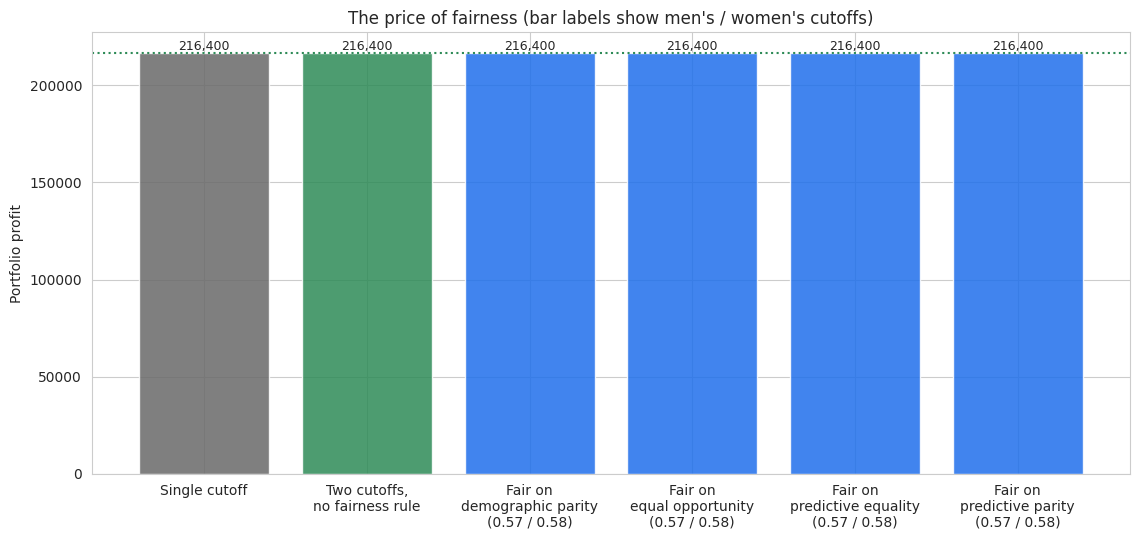

Free at your inputs: demographic parity, equal opportunity, predictive equality, predictive parity. The profit-best pair of cutoffs already satisfies
these measures, so their bars coincide with the green baseline — the fairness
constraint is not binding. This is why bars can look identical: several searches
landed on the same pair of cutoffs.

When every fairness is free, that is worth pausing on: it means the unfairness
you detected earlier came from forcing one shared cutoff onto a portfolio the
bias had made uneven. With stronger bias, real costs appear — try it.


In [15]:
names   = ["Single cutoff", "Two cutoffs,\nno fairness rule"]
profits = [single_profit, pair_baseline]
colors  = ["dimgrey", "seagreen"]
chosen_pairs = {}

for metric in METRICS:
    r = most_profitable_fair_pair(metric)
    if r is not None:
        short = METRICS[metric]["label"].split(" — ")[0]
        chosen_pairs[short] = (r["men_cutoff"], r["women_cutoff"], r["profit"])
        names.append("Fair on\n" + short.lower() + "\n({:.2f} / {:.2f})".format(
            r["men_cutoff"], r["women_cutoff"]))
        profits.append(r["profit"])
        colors.append("#1f6feb")

plt.figure(figsize=(11.5, 5.5))
bars = plt.bar(names, profits, color=colors, alpha=0.85)
plt.axhline(pair_baseline, color="seagreen", ls=":", lw=1.5)
plt.ylabel("Portfolio profit")
plt.title("The price of fairness (bar labels show men's / women's cutoffs)")
for b, p in zip(bars, profits):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), "{:,.0f}".format(p),
             ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

# Reading the chart out loud, whatever it shows
free    = [n for n, (tm, tw, p) in chosen_pairs.items() if pair_baseline - p <= 1e-9]
costly  = {n: pair_baseline - p for n, (tm, tw, p) in chosen_pairs.items() if pair_baseline - p > 1e-9}
missing = [METRICS[m]["label"].split(" — ")[0] for m in METRICS
           if METRICS[m]["label"].split(" — ")[0] not in chosen_pairs]

if free:
    print("Free at your inputs: {}. The profit-best pair of cutoffs already satisfies".format(
        ", ".join(free).lower()))
    print("these measures, so their bars coincide with the green baseline — the fairness")
    print("constraint is not binding. This is why bars can look identical: several searches")
    print("landed on the same pair of cutoffs.")
if costly:
    print()
    for n, c in sorted(costly.items(), key=lambda kv: -kv[1]):
        print("{} costs {:,.0f} against the two-cutoff baseline ({:.1f}% of profit).".format(
            n, c, 100 * c / max(abs(pair_baseline), 1e-9)))
if missing:
    print()
    print("Unachievable by cutoffs alone: {}.".format(", ".join(missing).lower()))
if free and not costly:
    print()
    print("When every fairness is free, that is worth pausing on: it means the unfairness")
    print("you detected earlier came from forcing one shared cutoff onto a portfolio the")
    print("bias had made uneven. With stronger bias, real costs appear — try it.")

## Experiments worth running

The most useful thing you can do now is re-run the notebook with different answers and watch the verdicts change. Three experiments in particular carry the whole lesson:

**Set the bias to 0.** No rewritten history, and the model should come out fair. This confirms the model itself isn't the villain.

**Keep the bias, but set proxy strength to 0.** Here is the surprise: gender-blindness *works*. With no feature revealing gender, the model has no channel to carry the bias, and the gaps collapse. Hiding gender fails in practice not because the idea is silly, but because real features are never this clean.

**Turn both up — bias 0.4, proxy 0.9.** Watch every check fail, the four-fifths rule break, and the repair get expensive. This is what inherited discrimination looks like at full strength.

## What to take away

Hiding gender did not make the model fair — bias travelled from the records, through the proxies, into the decisions. A sensible profit-maximising cutoff then locked it in. The repair meant treating groups differently on purpose, the opposite of blindness, and it usually costs money. And fixing one fairness definition bent the others, exactly as the theory says it must. There is no setting where a lender gets everything; there is only the choice of what to protect.

## Where to take it next

- Give the features real names — income, business sector, loan history — instead of anonymous columns.
- Let loan sizes differ per borrower, and study what happens when women receive systematically smaller loans.
- Re-run everything across many random seeds and put uncertainty bands on each fairness gap.
- Try repairing the data instead of the cutoffs: relabeling, reweighing, or fairness-constrained training, and compare the cost against the threshold repair.

## References

- Hardt, M., Price, E., & Srebro, N. (2016). *Equality of opportunity in supervised learning.* arXiv:1610.02413.
- Chouldechova, A. (2017). *Fair prediction with disparate impact.* Big Data, 5(2).
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2016). *Inherent trade-offs in the fair determination of risk scores.* arXiv:1609.05807.
- Verma, S., & Rubin, J. (2018). *Fairness definitions explained.* IEEE/ACM International Workshop on Software Fairness.
- Wattenberg, M., Viégas, F., & Hardt, M. *Attacking discrimination with smarter machine learning.* Google Research.


***

🎻